# Cinemática del IRB140 con Robotics Toolbox

Implementación y análisis cinemático del robot industrial ABB IRB140 utilizando la librería Robotics Toolbox de Peter Corke.

In [11]:
# Hacemos todas las importaciones necesarias
# numpy para manejar array y algebra lineal
import numpy as np
import scipy as sc
# la funcionalidad específica de robótica está en el toolbox
import roboticstoolbox as rtb
# spatialmath tiene define los grupos de transformaciones especiales: rotación SO3 y eculideo SE3
import spatialmath as sm
import spatialmath.base.symbolic as sym
import matplotlib.pyplot as plt  

%matplotlib inline

In [ ]:
# Cargamos la definición del robot
irb140_rtb = rtb.models.DH.IRB140()

# Mostramos los parámetros cinemáticos y los dinámicos
print(irb140_rtb)
print(irb140_rtb.dynamics())

DHRobot: IRB 140 (by ABB), 6 joints (RRRRRR), dynamics, geometry, standard DH parameters
┌─────┬───────┬──────┬────────┬─────────┬────────┐
│ θⱼ  │  dⱼ   │  aⱼ  │   ⍺ⱼ   │   q⁻    │   q⁺   │
├─────┼───────┼──────┼────────┼─────────┼────────┤
│  q1 │ 0.352 │ 0.07 │ -90.0° │ -180.0° │ 180.0° │
│  q2 │     0 │ 0.36 │   0.0° │ -100.0° │ 100.0° │
│  q3 │     0 │    0 │ -90.0° │ -220.0° │  60.0° │
│  q4 │  0.38 │    0 │  90.0° │ -200.0° │ 200.0° │
│  q5 │     0 │    0 │ -90.0° │ -120.0° │ 120.0° │
│  q6 │ 0.065 │    0 │   0.0° │ -400.0° │ 400.0° │
└─────┴───────┴──────┴────────┴─────────┴────────┘

┌──┬──┐
└──┴──┘

┌──────┬─────┬──────┬───────┬─────┬──────┬──────┐
│ name │ q0  │ q1   │ q2    │ q3  │ q4   │ q5   │
├──────┼─────┼──────┼───────┼─────┼──────┼──────┤
│   qr │  0° │ -90° │  90°  │  0° │  90° │ -90° │
│   qz │  0° │  0°  │  0°   │  0° │  0°  │  0°  │
│   qd │  0° │ -90° │  180° │  0° │  0°  │ -90° │
└──────┴─────┴──────┴───────┴─────┴──────┴──────┘

┌───────┬───────┬───────────────

   1         0         0         0.43      
   0        -1         0         0         
   0         0        -1        -0.093     
   0         0         0         1         



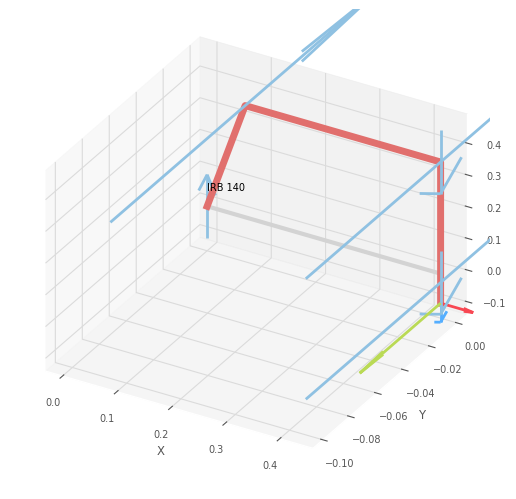

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'IRB 140')

<Figure size 640x480 with 0 Axes>

In [3]:
# Probamos la cinemática directa
qz = np.zeros(6)
POSE = irb140_rtb.fkine(qz)
print(POSE)

irb140_rtb.plot(qz)

# Modelo analizado en clase

Comparación con el modelo estándar de Robotics Toolbox: diferencias en signos de $\alpha_3$, $\alpha_4$, $\alpha_5$ y asignación de ternas. 

Se define un modelo personalizado ajustando offsets y ternas base y tool0 para coincidir con la definición del IRB140.

In [ ]:
irb140 = rtb.DHRobot(
    [
        rtb.RevoluteDH(alpha=-np.pi/2,a=0.07,d = 0.352),
        rtb.RevoluteDH(a=0.36,offset=-np.pi/2),
        rtb.RevoluteDH(alpha=np.pi/2,offset=np.pi),
        rtb.RevoluteDH(d=0.38, alpha=-np.pi/2),
        rtb.RevoluteDH(alpha=np.pi/2),
        rtb.RevoluteDH(d=0.065)
    ], name="IRB140")

print(irb140)

DHRobot: IRB140, 6 joints (RRRRRR), dynamics, standard DH parameters
┌────────────┬───────┬──────┬────────┐
│     θⱼ     │  dⱼ   │  aⱼ  │   ⍺ⱼ   │
├────────────┼───────┼──────┼────────┤
│  q1        │ 0.352 │ 0.07 │ -90.0° │
│  q2 - 90°  │     0 │ 0.36 │   0.0° │
│  q3 + 180° │     0 │    0 │  90.0° │
│  q4        │  0.38 │    0 │ -90.0° │
│  q5        │     0 │    0 │  90.0° │
│  q6        │ 0.065 │    0 │   0.0° │
└────────────┴───────┴──────┴────────┘

┌──┬──┐
└──┴──┘



[0. 0. 0. 0. 0. 0.]
   0         0         1         0.515     
   0         1         0         0         
  -1         0         0         0.712     
   0         0         0         1         



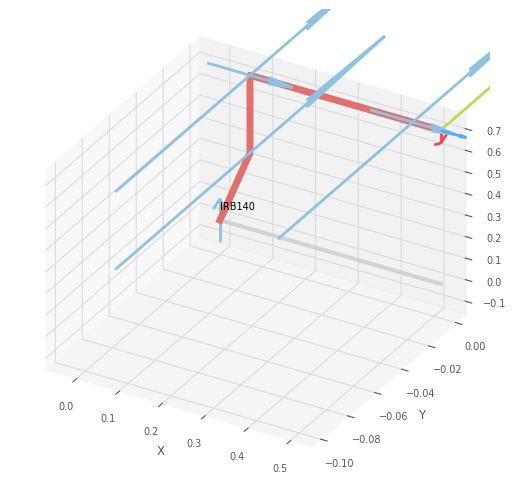

PyPlot3D backend, t = 0.05, scene:
  robot: Text(0.0, 0.0, 'IRB140')

<Figure size 640x480 with 0 Axes>

In [13]:
print(qz)
POSE = irb140.fkine(qz)

print(POSE)
irb140.plot(qz)

   0         0         1         0.515     
   0         1         0         0         
  -1         0         0         0.712     
   0         0         0         1         



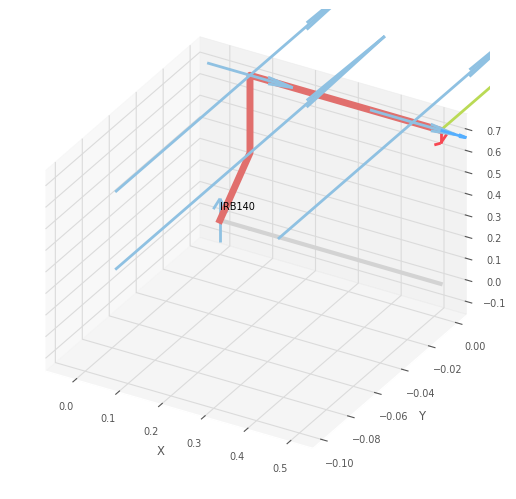

PCI:  [ 4.36566339e-11  1.62483723e+00  3.14159265e+00  3.14159265e+00
 -1.51675543e+00  3.14159265e+00] 
Deseado:  [0. 0. 0. 0. 0. 0.]
Delta Q= [ 4.36566339e-11  1.62483723e+00  3.14159265e+00  3.14159265e+00
 -1.51675543e+00  3.14159265e+00]


<Figure size 640x480 with 0 Axes>

In [32]:
# Probamos el pcd
POSE = irb140.fkine(qz)
print(POSE)
irb140.plot(qz)

# Probamos el pci
q = irb140.ikine_LM(POSE)
print("PCI: ",q.q,"\nDeseado: ",qz)
print("Delta Q=",q.q-qz)

In [ ]:
# Pongamos a prueba el pcd y pci numerico haciendo evaluaciones sobre valores random de q
def probar_acierto_IK(flag_q0_cercano = False):
  n_acierto = 0
  n_iter = 100
  for i in range(1,n_iter):
    q_deseado = (np.random.rand(6)-0.5)*2*np.pi
    POSE = irb140.fkine(q_deseado)
    if flag_q0_cercano :
      qseed = q_deseado+(np.random.rand(6)-0.5)*2*np.pi/100
      ik_solucion = irb140.ikine_LM(POSE,q0=qseed, slimit=100) 
    else:
      ik_solucion = irb140.ikine_LM(POSE) 
    if np.linalg.norm(q_deseado-ik_solucion.q)<1E-3:
       n_acierto += 1
  print("Cantidad de corridas: ",n_iter,"\nCantidad de aciertos: ",n_acierto)

print("Probamos con q0 random ******** ")
probar_acierto_IK()
print("\nProbamos con q0 cercano ******** ")
probar_acierto_IK(True)


Probamos con q0 random ******** 
Cantidad de corridas:  100 
Cantidad de aciertos:  21

Probamos con q0 cercano ******** 
Cantidad de corridas:  100 
Cantidad de aciertos:  99


# PCI analítico + cálculo de configuraciones 

Esto fue un papelón. Ahora voy a sumarle el calculo del PCI analítico

In [91]:
class irb140_clase(rtb.DHRobot):
    def __init__(self, *args, **kwargs):
        super().__init__([
        rtb.RevoluteDH(alpha=-np.pi/2,a=0.07,d = 0.352),
        rtb.RevoluteDH(a=0.36,offset=-np.pi/2),
        rtb.RevoluteDH(alpha=np.pi/2,offset=np.pi),
        rtb.RevoluteDH(d=0.38, alpha=-np.pi/2),
        rtb.RevoluteDH(alpha=np.pi/2),
        rtb.RevoluteDH(d=0.065)
        ], name="IRB140")

    def get_config(self,q):
        g1 = np.sign(self.links[3].d * np.sin(q[1]+self.links[1].offset +q[2]+self.links[2].offset) + self.links[1].a * np.cos(q[1]+self.links[1].offset) + self.links[0].a)
        g2 = np.sign(np.cos(q[2]+self.links[2].offset))
        g3 = np.sign(np.sin(q[4]+self.links[4].offset))
        return np.array([g1,g2,g3])
    
    def ikine_a(self,POSE,conf=[1,-1,1],q1_actual=0,q4_actual=0):
        # Problema inversor para el robot ABB IRB 140
        # Se determina el vector q
        status = -1

        # Inicializo el vector de variables articulares
        q = np.zeros(6) 

        # Posición
        POSE = sm.SE3(0,0,-self.links[0].d) @ POSE @ sm.SE3(0,0,-self.links[5].d)
        px, py, pz = POSE.t

        # Calculo q1 
        s1 = conf[0]*py
        c1 = conf[0]*px
        if px==0 and py==0:
            q[0] = q1_actual
        else:
            q[0] = np.arctan2(s1,c1)

        # Calculo q3 (codo)
        s3 = ((px*np.cos(q[0]) + py*np.sin(q[0]) - self.links[0].a)**2 + pz**2 - self.links[1].a**2 - self.links[3].d**2)/(2*self.links[1].a*self.links[3].d);
        if (np.abs(s3) > 1):
            print('ERROR: Punto no alcanzable.')
            return q, status
        c3 = conf[1]*np.sqrt(1-s3**2)
        q[2] = np.arctan2(s3,c3)

        # Calculo q2
        s2 = (px*np.cos(q[0]) + py*np.sin(q[0]) - self.links[0].a)*(self.links[3].d*np.cos(q[2])) - (self.links[3].d*np.sin(q[2]) + self.links[1].a)*pz
        c2 = (px*np.cos(q[0]) + py*np.sin(q[0]) - self.links[0].a)*(self.links[3].d*np.sin(q[2]) + self.links[1].a) + (self.links[3].d*np.cos(q[2]))*pz
        q[1] = np.arctan2(s2,c2)

        # Calculo el problema de orientacion
        # Calculo R_63
        A60 = self.fkine(q-self.offset)
        R_30 = A60.R
        R_63 = R_30.T @ POSE.R

        # Calculo q5
        c5 = R_63[2,2]
        c5 = np.clip(c5,-1,1)
        q[4] = np.arctan2(conf[2]*np.sqrt(1-c5**2),c5)

        if np.abs(R_63[1,2])<1E-9 and np.abs(R_63[0,2])<1E-9:
            q[3] = q4_actual
            q[5] = np.arctan2(R_63[1,0],R_63[0,0])-q4_actual
        else:
            # Calculo de q4
            s4 = conf[2]*R_63[1,2]
            c4 = conf[2]*R_63[0,2]
            q[3] = np.arctan2(s4,c4)

            # Calculo de q6
            s6 = conf[2]*R_63[2,1]
            c6 = -conf[2]*R_63[2,0]
            q[5] = np.arctan2(s6,c6)

        status = 0
        q = np.angle(np.exp(1j*(q-self.offset)))
        return q, status


robot = irb140_clase()
print(robot)


DHRobot: IRB140, 6 joints (RRRRRR), dynamics, standard DH parameters
┌────────────┬───────┬──────┬────────┐
│     θⱼ     │  dⱼ   │  aⱼ  │   ⍺ⱼ   │
├────────────┼───────┼──────┼────────┤
│  q1        │ 0.352 │ 0.07 │ -90.0° │
│  q2 - 90°  │     0 │ 0.36 │   0.0° │
│  q3 + 180° │     0 │    0 │  90.0° │
│  q4        │  0.38 │    0 │ -90.0° │
│  q5        │     0 │    0 │  90.0° │
│  q6        │ 0.065 │    0 │   0.0° │
└────────────┴───────┴──────┴────────┘

┌──┬──┐
└──┴──┘



In [92]:
n_acierto = 0
n_iter = 100
for i in range(0,n_iter):
    q_deseado = (np.random.rand(6)-0.5)*2*np.pi
    POSE = robot.fkine(q_deseado)
    conf = robot.get_config(q_deseado)
    q,status = robot.ikine_a(POSE,conf=conf,q1_actual=q_deseado[0],q4_actual=q_deseado[3])
    if np.linalg.norm(q_deseado-q)<1E-3:
        n_acierto += 1
    else:
        print(f"ERROR:\nDeseado: {q_deseado}    config={conf}")
        print("Alcanzado: ",q)

print("Cantidad de corridas: ",n_iter,"\nCantidad de aciertos: ",n_acierto)

Cantidad de corridas:  100 
Cantidad de aciertos:  100


# Singularidades

En esta sección se analizan tres singularidades principales del ABB IRB140:

- **Singularidad de la muñeca** (joints 4-5-6)
- **Singularidad del brazo** (configuración del hombro/codo con muñeca alineada)
- **Singularidad del codo** (ángulo de codo crítico)

El objetivo es usar matrices Jacobianas y descomposición SVD para identificar modos de movimiento prohibidos y espacios nulos en velocidad.


## Singularidad de muñeca

Se evalúa el Jacobiano en q = [0, 0, 0, 0, 0, 0] donde el eje 4 y el 6 están alineados. En esta condición se espera pérdida de grado de libertad en la parte rotacional y un espacio nulo asociado a la dirección bloqueada.

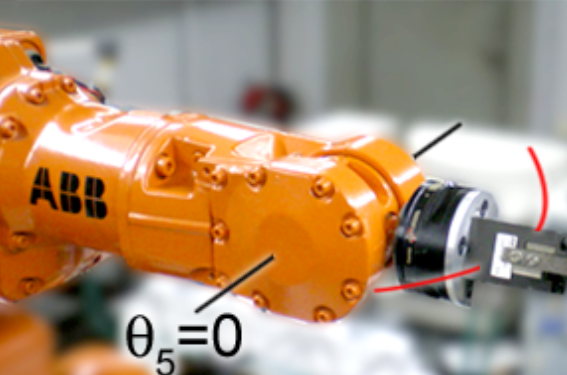


In [15]:
# Singularidad de muñeca en q = [0,0,0,0,0,0]
np.set_printoptions(precision=3,suppress=True)
qsing = np.array([[0,0,0,0,0,0]])
J = robot.jacob0(qsing)

# Reportar resultados clave 
print("Determinante Jacobiano:", np.linalg.det(J))
print("Espacio nulo de J:")
print(sc.linalg.null_space(J).ravel())
print("Espacio nulo de J^T:")
print(sc.linalg.null_space(J.T).ravel())

Determinante Jacobiano: 8.59527065895444e-67
Espacio nulo de J:
[ 0.    -0.     0.    -0.707 -0.     0.707]
Espacio nulo de J^T:
[ 0.    -0.912 -0.     0.     0.     0.41 ]


## Singularidad de brazo

En esta parte se busca $\mathbf{q}$ que lleva la muñeca sobre el eje 1. Se analiza cómo se comporta el Jacobiano (determinante cero) y el espacio nulo en velocidades cartesianas y articulares.

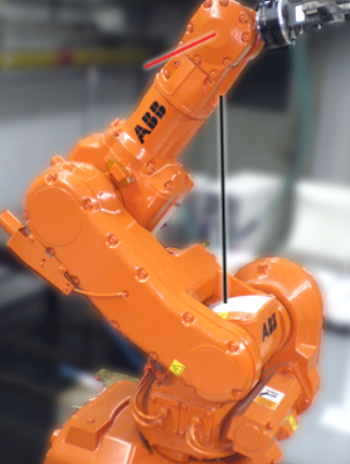

Evaluamos el jacobiano en la singularidad del brazo. Para esto vamos a averiguar el q que lleva la muñeca a un punto del eje 1.

Atención: dejé la herramienta con $\mathbf{z}_\text{tool0}$ en dirección de $\mathbf{z}_0$


In [ ]:
np.set_printoptions(precision=3,suppress=True)

POSE = sm.SE3.Trans(0,0,0.500) @ sm.SE3.Eul(0,0,0)


print(POSE)
# Si uso el analítico anda de una 
qsing,_ = robot.ikine_a(POSE,conf=[1,1,1])
#qsing = robot.ikine_LM(POSE).q

print("q singular:",qsing)
J = robot.jacob0(qsing)
print("Determinante: ",np.linalg.det(J))
print("Espacio Nulo de J:\n",sc.linalg.null_space(J).ravel())
print("Espacio Nulo de J transpuesto:\n",sc.linalg.null_space(J.transpose()).ravel())

U,S,Vt = sc.linalg.svd(J)
print("Valores Singulares: ",S)
print("Ultima fila de Vt: ",Vt[-1,:])
print("Ultima columna de U: ",U[:,-1])


   1         0         0         0         
   0         1         0         0         
   0         0         1         0.5       
   0         0         0         1         

q singular: [0.    0.71  3.072 0.    0.93  0.   ]
Determinante:  1.5186582488885608e-17
Espacio Nulo de J:
 [ 0.707  0.     0.    -0.    -0.    -0.707]
Espacio Nulo de J transpuesto:
 [ 0. -1.  0. -0.  0.  0.]
Valores Singulares:  [1.798 1.575 0.72  0.345 0.22  0.   ]
Ultima fila de Vt:  [ 0.707  0.     0.    -0.    -0.    -0.707]
Ultima columna de U:  [ 0.  1.  0.  0.  0. -0.]


## Singularidad de codo

Corresponde a la configuración donde $q_3 = -\pi/2$ (o equivalente) y el eslabón del brazo está alineado de modo que el grado de libertad de rotación del codo se pierde. Aquí se analiza el Jacobiano y los modos singulares con SVD.

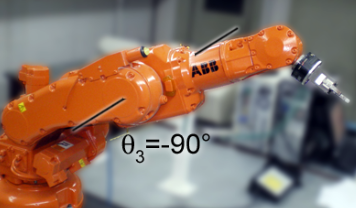

In [52]:
# Evaluamos la singularidad del codo
qsing[2] = -np.pi/2

J = robot.jacob0(qsing)

U,S,Vt = sc.linalg.svd(J)
print("Valores Singulares: ",S)
print("Espacio Nulo de J:\n",Vt[-1,:])
print("Espacio Nulo de J transpuesto:\n",U[:,-1])


Valores Singulares:  [1.859 1.43  1.086 0.488 0.285 0.   ]
Espacio Nulo de J:
 [ 0.     0.419 -0.816  0.     0.397  0.   ]
Espacio Nulo de J transpuesto:
 [-0.652  0.    -0.758  0.     0.     0.   ]


In [ ]:
# No dice demasiado, Lo mejor sería proyectar la velocidad en terna 3
# En este caso la dirección prohibida debería ser z_3
POSE = robot.fkine_all(qsing)
R_03 = POSE[3].R
null_Jt = R_03.transpose() @ U[0:3,-1].transpose()
print(null_Jt)

[-0.  0. -1.]


# Ejercicio

Graficar el perfil de posiciones articulares y espaciales (solo posición) para un movimiento en línea recta en la dirección Y_0

In [104]:

# Resolución
# Primero armamos una función que simule el movimiento, porque al estudiar distintos
# casos es mejor no repetir código

def simular_movimiento(POSE_ini,POSE_fin,tiempo_mov=2,n_steps=200):
  # Inicializo las variables que definen el movimiento deseado
  dx = (POSE_fin.t - POSE_ini.t)/n_steps
  dx = dx.reshape(3,1)
  dw = np.zeros((3,1))
  dt = tiempo_mov/n_steps

  q_acum = np.empty((n_steps, 6))
  qp_acum = np.empty((n_steps, 6))
  X_acum = np.empty((n_steps, 3))

  q,_ = robot.ikine_a(POSE_ini)
  for idx_step in range(n_steps):
      J = robot.jacob0(q)
      J_pinv = sc.linalg.pinv(J)
      V = np.vstack((dx, dw)) / dt
      qp = np.reshape(J_pinv @ V, (6,))

      q += qp * dt
      q_acum[idx_step, :] = q
      qp_acum[idx_step, :] = qp
      X_acum[idx_step, :] = np.reshape(robot.fkine(q).t, (1, 3))

  # Gráficos
  #robot.plot(q_acum, backend='pyplot')

  t = np.linspace(0, 1, n_steps)
  plt.subplot(2, 1, 1)
  plt.plot(t, q_acum * 180 / np.pi)
  plt.title('Posiciones articulares')
  plt.xlabel('Tiempo [s]')
  plt.ylabel('$q(t)$ [°]')
  plt.legend(['$q_1$', '$q_2$', '$q_3$', '$q_4$', '$q_5$', '$q_6$'])
  plt.show()

  plt.subplot(2,1,2)
  plt.plot(t, qp_acum*180/np.pi)
  plt.title('Velocidades articulares')
  plt.xlabel('Tiempo [s]')
  plt.ylabel('$\dot{q}(t)$ [°/s]')
  plt.legend(['$\dot{q}_1$','$\dot{q}_2$','$\dot{q}_3$','$\dot{q}_4$','$\dot{q}_5$','$\dot{q}_6$'])
  plt.show()

  plt.plot(t,X_acum[:,:]*1000)
  plt.title('Posiciones cartesianas')
  plt.xlabel('Tiempo [s]')
  plt.ylabel('POS [mm]')
  plt.legend(['$x$', '$y$','$z$'])
  plt.show()

## Pasando cerca de la singularidad del brazo

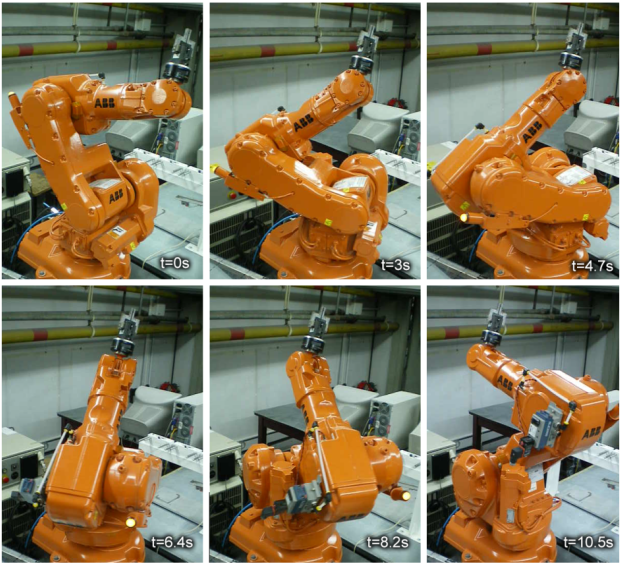

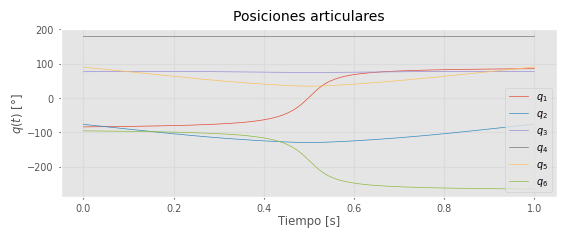

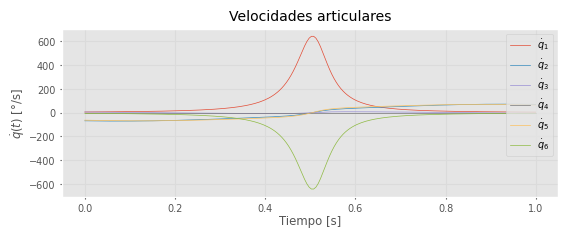

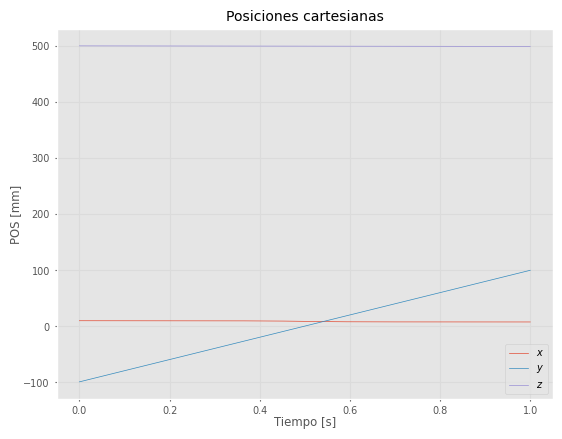

In [105]:
# Esto pasa por la singularidad del brazo
POSE_ini = sm.SE3.Trans(0.01,-0.100,0.5)
POSE_fin = sm.SE3.Trans(0.01,0.100,0.5)
simular_movimiento(POSE_ini,POSE_fin)


## Pasando cerca de la singularidad de la muñeca

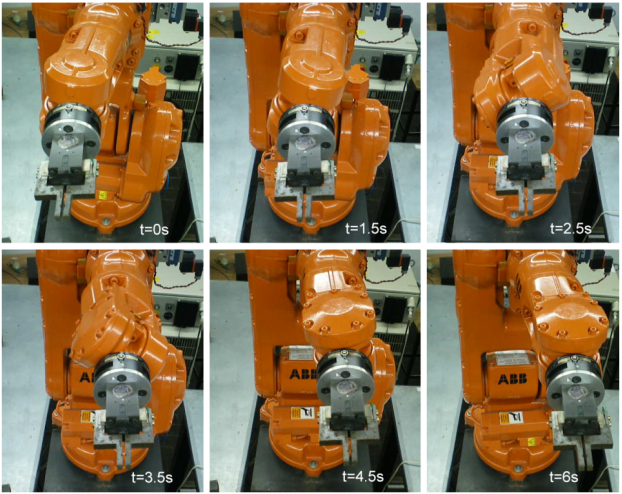

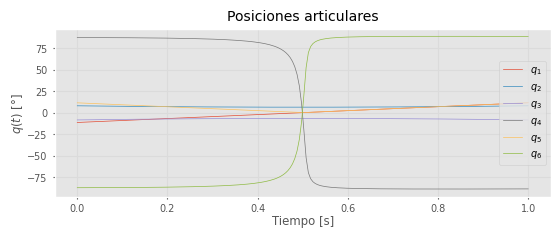

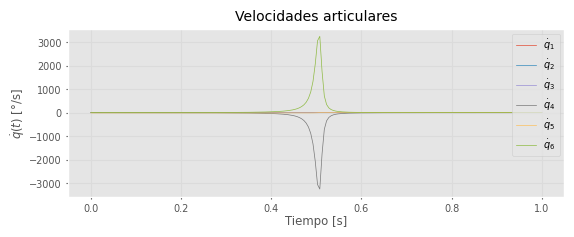

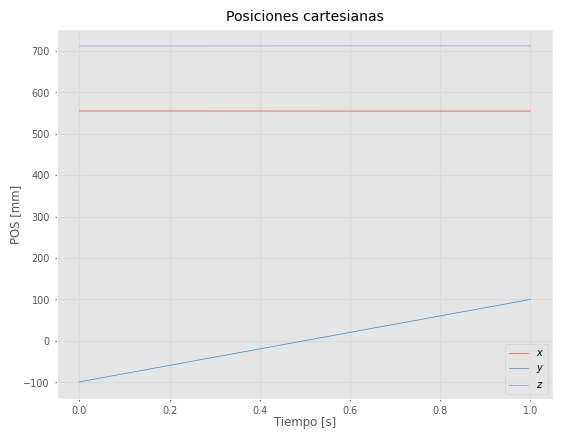

In [106]:
# Esto pasa por la singularidad de la muñeca
POSE_zero = irb140.fkine(qz)
POSE_ini = POSE_zero * sm.SE3(0,-0.100,0.04)
POSE_fin = POSE_zero * sm.SE3(0,0.100,0.04)

simular_movimiento(POSE_ini,POSE_fin)